# Module 2: Symptom-Based Disease Prediction


## Step 1 – Install Dependencies

In [ ]:
!pip install transformers datasets scikit-learn gradio torch --quiet

## Step 2 – Load Dataset
Downloaded from Kaggle: https://www.kaggle.com/datasets/niyarbarman/symptom2disease


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('Symptom2Disease.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nDisease classes ({df['label'].nunique()}):")
print(df['label'].value_counts())

Dataset shape: (1200, 3)
Columns: ['Unnamed: 0', 'label', 'text']

Disease classes (24):
label
Psoriasis                          50
Varicose Veins                     50
Typhoid                            50
Chicken pox                        50
Impetigo                           50
Dengue                             50
Fungal infection                   50
Common Cold                        50
Pneumonia                          50
Dimorphic Hemorrhoids              50
Arthritis                          50
Acne                               50
Bronchial Asthma                   50
Hypertension                       50
Migraine                           50
Cervical spondylosis               50
Jaundice                           50
Malaria                            50
urinary tract infection            50
allergy                            50
gastroesophageal reflux disease    50
drug reaction                      50
peptic ulcer disease               50
diabetes                       

In [ ]:
# Encode disease labels to integers
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
num_classes = len(le.classes_)
print(f"Number of classes: {num_classes}")
print(f"Sample:\n{df[['text', 'label', 'label_enc']].head(3)}")

Number of classes: 24
Sample:
                                                text      label  label_enc
0  I have been experiencing a skin rash on my arm...  Psoriasis         15
1  My skin has been peeling, especially on my kne...  Psoriasis         15
2  I have been experiencing joint pain in my fing...  Psoriasis         15


In [ ]:
# Train / Validation / Test split (70 / 15 / 15)
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label_enc'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label_enc'], random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 840 | Val: 180 | Test: 180


## Step 3 – Dataset & Utility Setup

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class SymptomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts   = texts.tolist()
        self.labels  = labels.tolist()
        self.tok     = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS    = 4
BATCH     = 16
LR        = 2e-5
MAX_LEN   = 128

print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
def train_model(model_name, train_df, val_df, num_classes, epochs=EPOCHS):
    """Train a transformer model and return the model + training history."""
    print(f"\n{'='*50}")
    print(f"Training: {model_name}")
    print(f"{'='*50}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModelForSequenceClassification.from_pretrained(
                    model_name, num_labels=num_classes, ignore_mismatched_sizes=True)
    model.to(DEVICE)

    train_loader = DataLoader(
        SymptomDataset(train_df['text'], train_df['label_enc'], tokenizer, MAX_LEN),
        batch_size=BATCH, shuffle=True)
    val_loader   = DataLoader(
        SymptomDataset(val_df['text'], val_df['label_enc'], tokenizer, MAX_LEN),
        batch_size=BATCH)

    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=total_steps // 10, num_training_steps=total_steps)

    history = {'train_loss': [], 'val_f1': []}
    best_f1, best_state = 0, None

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            out = model(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE),
                labels=batch['label'].to(DEVICE)
            )
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += out.loss.item()

        avg_loss = total_loss / len(train_loader)

        # --- Validate ---
        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for batch in val_loader:
                out = model(
                    input_ids=batch['input_ids'].to(DEVICE),
                    attention_mask=batch['attention_mask'].to(DEVICE)
                )
                preds.extend(out.logits.argmax(-1).cpu().numpy())
                trues.extend(batch['label'].numpy())

        val_f1 = f1_score(trues, preds, average='weighted')
        history['train_loss'].append(avg_loss)
        history['val_f1'].append(val_f1)

        print(f"  Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1   = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, tokenizer, history

In [ ]:
def evaluate_model(model, tokenizer, test_df, label_names, model_label):
    """Evaluate on test set and print metrics."""
    test_loader = DataLoader(
        SymptomDataset(test_df['text'], test_df['label_enc'], tokenizer, MAX_LEN),
        batch_size=BATCH)

    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in test_loader:
            out = model(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE)
            )
            preds.extend(out.logits.argmax(-1).cpu().numpy())
            trues.extend(batch['label'].numpy())

    acc = accuracy_score(trues, preds)
    f1  = f1_score(trues, preds, average='weighted')

    print(f"\n--- {model_label} Test Results ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(classification_report(trues, preds, target_names=label_names))

    return acc, f1, preds, trues

## Step 4 – Train All Three Models
> **Note:** Each model takes ~10–20 minutes on Colab T4 GPU. BioBERT may take slightly longer.

In [ ]:
# Model 1 – BERT (General purpose baseline)
bert_model, bert_tok, bert_hist = train_model(
    'bert-base-uncased', train_df, val_df, num_classes)


Training: bert-base-uncased


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/4 | Loss: 3.1072 | Val F1: 0.2394
  Epoch 2/4 | Loss: 2.6506 | Val F1: 0.5195
  Epoch 3/4 | Loss: 2.2372 | Val F1: 0.6803
  Epoch 4/4 | Loss: 2.0267 | Val F1: 0.7008


In [ ]:
# Model 2 – DistilBERT (Lightweight, faster baseline)
distil_model, distil_tok, distil_hist = train_model(
    'distilbert-base-uncased', train_df, val_df, num_classes)


Training: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

HTTP Error 500 thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/4 | Loss: 3.1264 | Val F1: 0.4023
  Epoch 2/4 | Loss: 2.6706 | Val F1: 0.7794
  Epoch 3/4 | Loss: 2.2109 | Val F1: 0.7975
  Epoch 4/4 | Loss: 1.9748 | Val F1: 0.8006


In [ ]:
# Model 3 – BioBERT (Domain-specific, expected best)
bio_model, bio_tok, bio_hist = train_model(
    'dmis-lab/biobert-base-cased-v1.2', train_df, val_df, num_classes)


Training: dmis-lab/biobert-base-cased-v1.2


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

  Epoch 1/4 | Loss: 3.0894 | Val F1: 0.3178
  Epoch 2/4 | Loss: 2.3277 | Val F1: 0.7323
  Epoch 3/4 | Loss: 1.7375 | Val F1: 0.8133
  Epoch 4/4 | Loss: 1.4508 | Val F1: 0.8133


## Step 5 – Evaluate All Models on Test Set

In [ ]:
label_names = le.classes_.tolist()

bert_acc,   bert_f1,   bert_preds,   bert_trues   = evaluate_model(bert_model,  bert_tok,  test_df, label_names, 'BERT')
distil_acc, distil_f1, distil_preds, distil_trues = evaluate_model(distil_model, distil_tok, test_df, label_names, 'DistilBERT')
bio_acc,    bio_f1,    bio_preds,    bio_trues     = evaluate_model(bio_model,    bio_tok,   test_df, label_names, 'BioBERT')


--- BERT Test Results ---
Accuracy : 0.7611
F1 Score : 0.7221
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00         7
                      Arthritis       0.78      1.00      0.88         7
               Bronchial Asthma       0.75      0.86      0.80         7
           Cervical spondylosis       1.00      1.00      1.00         8
                    Chicken pox       1.00      0.50      0.67         8
                    Common Cold       1.00      0.29      0.44         7
                         Dengue       0.55      0.75      0.63         8
          Dimorphic Hemorrhoids       1.00      1.00      1.00         8
               Fungal infection       1.00      1.00      1.00         7
                   Hypertension       0.71      0.71      0.71         7
                       Impetigo       0.89      1.00      0.94         8
                       Jaundice       1.00      1.00      1.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- DistilBERT Test Results ---
Accuracy : 0.8111
F1 Score : 0.7918
                                 precision    recall  f1-score   support

                           Acne       0.88      1.00      0.93         7
                      Arthritis       1.00      1.00      1.00         7
               Bronchial Asthma       0.88      1.00      0.93         7
           Cervical spondylosis       0.89      1.00      0.94         8
                    Chicken pox       0.71      0.62      0.67         8
                    Common Cold       0.62      0.71      0.67         7
                         Dengue       1.00      0.50      0.67         8
          Dimorphic Hemorrhoids       1.00      1.00      1.00         8
               Fungal infection       1.00      1.00      1.00         7
                   Hypertension       0.88      1.00      0.93         7
                       Impetigo       1.00      0.88      0.93         8
                       Jaundice       0.70      1.00  

## Step 6 – Comparison Table (Thesis Figure)

     Model  Accuracy  F1 Score
      BERT  0.761111  0.722129
DistilBERT  0.811111  0.791752
   BioBERT  0.855556  0.840635


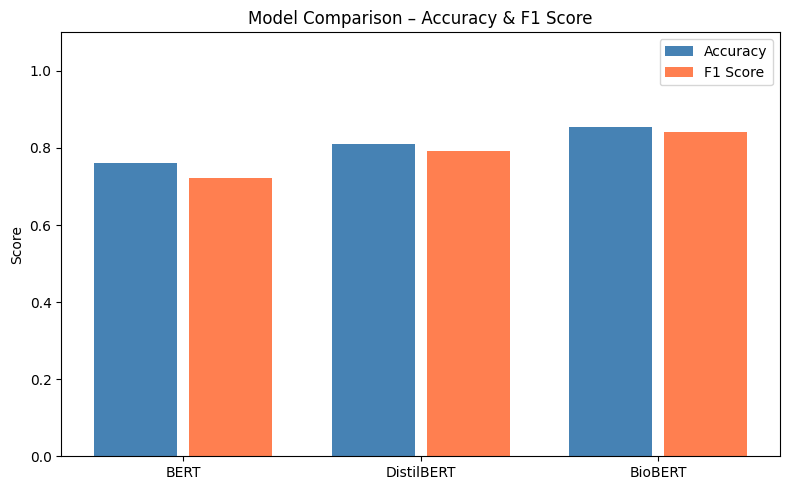

Saved: model_comparison.png


In [ ]:
results = pd.DataFrame({
    'Model':    ['BERT', 'DistilBERT', 'BioBERT'],
    'Accuracy': [bert_acc, distil_acc, bio_acc],
    'F1 Score': [bert_f1, distil_f1, bio_f1]
})
print(results.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
ax.bar(x - 0.2, results['Accuracy'], 0.35, label='Accuracy', color='steelblue')
ax.bar(x + 0.2, results['F1 Score'], 0.35, label='F1 Score', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(['BERT', 'DistilBERT', 'BioBERT'])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison – Accuracy & F1 Score')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Saved: model_comparison.png")

## Step 7 – Training Loss Curves


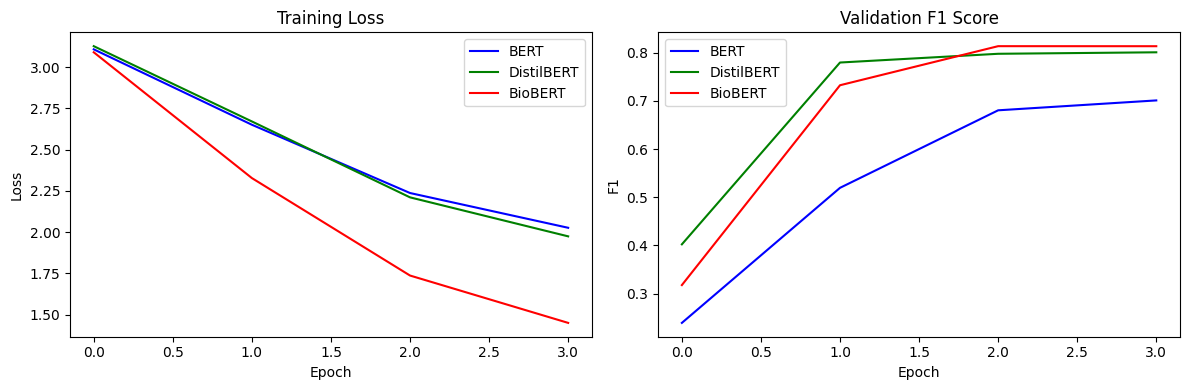

Saved: training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for hist, name, color in [
    (bert_hist, 'BERT', 'blue'),
    (distil_hist, 'DistilBERT', 'green'),
    (bio_hist, 'BioBERT', 'red')
]:
    axes[0].plot(hist['train_loss'], label=name, color=color)
    axes[1].plot(hist['val_f1'],     label=name, color=color)

axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].set_title('Validation F1 Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Saved: training_curves.png")

## Step 8 – BioBERT Confusion Matrix

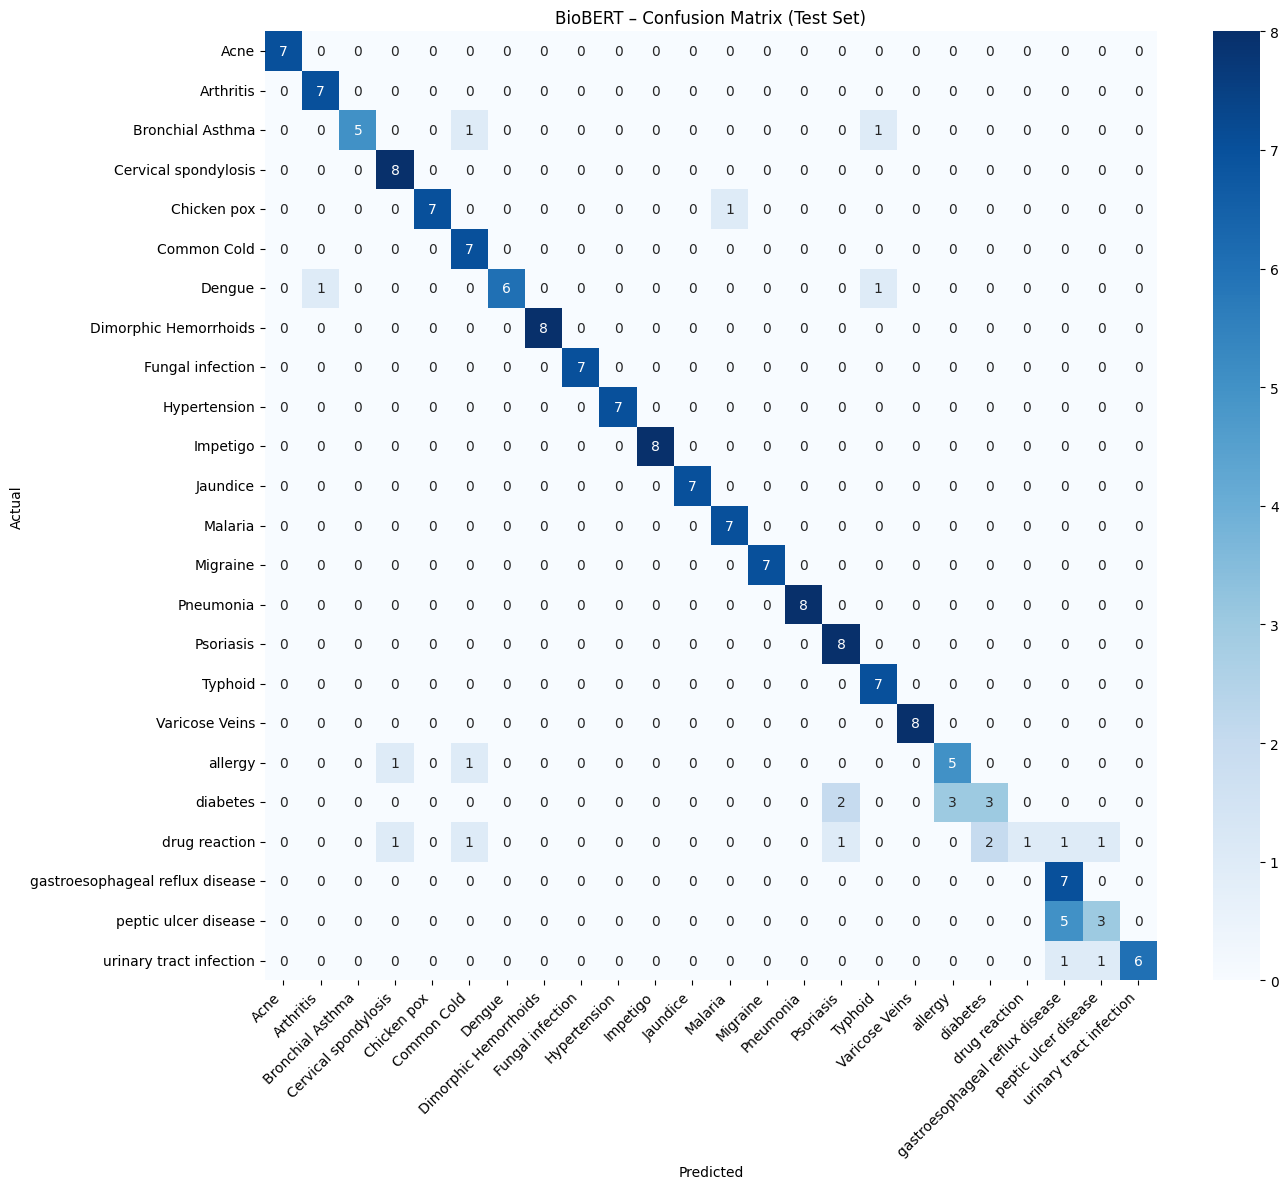

Saved: biobert_confusion_matrix.png


In [ ]:
cm = confusion_matrix(bio_trues, bio_preds)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_title('BioBERT – Confusion Matrix (Test Set)')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('biobert_confusion_matrix.png', dpi=150)
plt.show()
print("Saved: biobert_confusion_matrix.png")

## Step 9 – Save BioBERT Model

In [ ]:
import json

bio_model.save_pretrained('biobert_symptom_model')
bio_tok.save_pretrained('biobert_symptom_model')

# Save label mapping
with open('biobert_symptom_model/label_map.json', 'w') as f:
    json.dump({i: name for i, name in enumerate(label_names)}, f)

print("BioBERT model saved to: biobert_symptom_model/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BioBERT model saved to: biobert_symptom_model/


## Step 10 – Gradio Web Interface
Enter your symptoms in plain English and get a disease prediction with confidence score.

In [ ]:
import gradio as gr
import torch.nn.functional as F

def predict_disease(symptom_text):
    """Takes a symptom sentence and returns top 3 disease predictions."""
    if not symptom_text.strip():
        return "Please enter your symptoms."

    bio_model.eval()
    enc = bio_tok(
        symptom_text,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    with torch.no_grad():
        out = bio_model(
            input_ids=enc['input_ids'].to(DEVICE),
            attention_mask=enc['attention_mask'].to(DEVICE)
        )

    probs       = F.softmax(out.logits, dim=-1).squeeze().cpu()
    top3_idx    = probs.topk(3).indices.tolist()
    top3_probs  = probs.topk(3).values.tolist()

    result = "### 🏥 MedGuard AI – Disease Prediction\n\n"
    result += f"**Input:** {symptom_text}\n\n"
    result += "---\n"
    result += "**Top Predictions:**\n\n"

    medals = ['🥇', '🥈', '🥉']
    for i, (idx, prob) in enumerate(zip(top3_idx, top3_probs)):
        disease = label_names[idx]
        result += f"{medals[i]} **{disease}** — {prob*100:.1f}% confidence\n\n"

    result += "\n---\n⚠️ *This is an AI research prototype. Always consult a doctor.*"
    return result


demo = gr.Interface(
    fn=predict_disease,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Describe your symptoms here, e.g. 'I have a high fever, body aches, and fatigue for the past 3 days'",
        label="Symptom Description"
    ),
    outputs=gr.Markdown(label="Prediction Result"),
    title="MedGuard AI – Symptom-Based Disease Prediction",
    description="Enter your symptoms in plain English. BioBERT will predict the most likely diseases and their confidence scores.",
    examples=[
        ["I have been experiencing high fever, chills, and severe headache for the past two days"],
        ["My skin is itchy with red patches and blisters appearing on my arms"],
        ["I feel very tired, have joint pain and my eyes have turned yellowish"],
        ["I have a persistent cough, chest pain and difficulty breathing"]
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://63b8c65c2f3f9a2f4f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
